# Assignment 2 – PCA Python Implementation

## Q1. Mean centering

In [19]:
import numpy as np

X = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

mean = np.mean(X, axis=0)
X_centered = X - mean

print("Mean:", mean)
print("Centered data:")
print(X_centered)


Mean: [4. 3.]
Centered data:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]


## Q2. Mean, centering and scatter plot

Mean: [3. 6.]
Centered data:
[[-2. -4.]
 [-1. -2.]
 [ 0.  0.]
 [ 1.  2.]
 [ 2.  4.]]


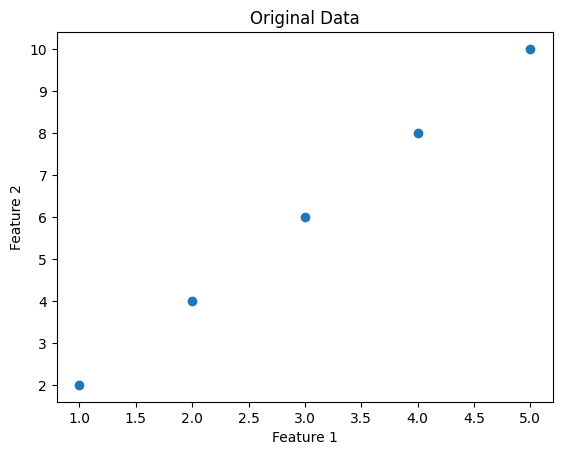

Observation: The data is distributed along a strong positive linear direction.


In [20]:
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],
    [2, 4],
    [3, 6],
    [4, 8],
    [5, 10]
])

mean = np.mean(X, axis=0)
X_centered = X - mean

print("Mean:", mean)
print("Centered data:")
print(X_centered)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.show()

print("Observation: The data is distributed along a strong positive linear direction.")


## Q3. Covariance matrix of Q1 centered data

In [21]:
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix:")
print(cov_matrix)
print("Variance of Feature 1:", cov_matrix[0, 0])
print("Variance of Feature 2:", cov_matrix[1, 1])


Covariance matrix:
[[ 2.5  5. ]
 [ 5.  10. ]]
Variance of Feature 1: 2.5
Variance of Feature 2: 10.0


## Q4. Mean, centered data and covariance matrix

In [22]:
X = np.array([
    [1, 2],
    [2, 3],
    [3, 5],
    [4, 7],
    [5, 8]
])

mean = np.mean(X, axis=0)
centered = X - mean
cov_matrix = np.cov(centered, rowvar=False)

print("Mean:", mean)
print("Centered data:")
print(centered)
print("Covariance matrix:")
print(cov_matrix)


Mean: [3. 5.]
Centered data:
[[-2. -3.]
 [-1. -2.]
 [ 0.  0.]
 [ 1.  2.]
 [ 2.  3.]]
Covariance matrix:
[[2.5 4. ]
 [4.  6.5]]


## Q5. Strongly positively correlated features

In [23]:
x1 = np.array([1, 2, 3, 4, 5])
x2 = np.array([2, 4, 6, 8, 10])

X = np.column_stack((x1, x2))
cov_matrix = np.cov(X, rowvar=False)

print("Covariance matrix:")
print(cov_matrix)
print("Observation: The off-diagonal covariance is positive and large, showing strong positive correlation.")


Covariance matrix:
[[ 2.5  5. ]
 [ 5.  10. ]]
Observation: The off-diagonal covariance is positive and large, showing strong positive correlation.


## Q6. Negatively correlated features

In [24]:
x1 = np.array([1, 2, 3, 4, 5])
x2 = np.array([10, 8, 6, 4, 2])

X_negative = np.column_stack((x1, x2))
cov_negative = np.cov(X_negative, rowvar=False)

print("Negative covariance matrix:")
print(cov_negative)
print("Comparison: Positive correlation gives a positive off-diagonal covariance; negative correlation gives a negative one.")


Negative covariance matrix:
[[ 2.5 -5. ]
 [-5.  10. ]]
Comparison: Positive correlation gives a positive off-diagonal covariance; negative correlation gives a negative one.


## Q7. Eigenvalues and eigenvectors

In [25]:
C = np.array([
    [4, 2],
    [2, 3]
])

eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:")
print(eigenvectors)
print("Eigenvector for largest eigenvalue:", eigenvectors[:, 0])


Eigenvalues: [5.56155281 1.43844719]
Eigenvectors:
[[-0.78820544  0.61541221]
 [-0.61541221 -0.78820544]]
Eigenvector for largest eigenvalue: [-0.78820544 -0.61541221]


## Q8. Diagonal covariance matrix

In [26]:
C = np.array([
    [5, 0],
    [0, 2]
])

eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:")
print(eigenvectors)
print("First principal component direction:", eigenvectors[:, 0])


Eigenvalues: [5. 2.]
Eigenvectors:
[[1. 0.]
 [0. 1.]]
First principal component direction: [1. 0.]


## Q9. Sort eigenvalues and eigenvectors

In [27]:
C = np.array([
    [6, 4],
    [4, 3]
])

eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]

sorted_values = eigenvalues[idx]
sorted_vectors = eigenvectors[:, idx]

print("Sorted eigenvalues:", sorted_values)
print("Rearranged eigenvectors:")
print(sorted_vectors)


Sorted eigenvalues: [8.77200187 0.22799813]
Rearranged eigenvectors:
[[-0.82192562  0.56959484]
 [-0.56959484 -0.82192562]]


## Q10. PCA from scratch without sklearn

In [28]:
X = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

# 1. Mean centering
mean = np.mean(X, axis=0)
X_centered = X - mean

# 2. Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# 3. Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 4. Sort by decreasing eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 5. Select all principal components
components = eigenvectors

# 6. Transform data
X_transformed = X_centered @ components

print("Mean:", mean)
print("Centered data:")
print(X_centered)
print("Covariance matrix:")
print(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:")
print(eigenvectors)
print("Transformed data:")
print(X_transformed)


Mean: [4. 3.]
Centered data:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]
Covariance matrix:
[[2.5 2.5]
 [2.5 2.5]]
Eigenvalues: [5. 0.]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Transformed data:
[[-2.82842712  0.        ]
 [-1.41421356  0.        ]
 [ 0.          0.        ]
 [ 1.41421356  0.        ]
 [ 2.82842712  0.        ]]


## Q11. Project centered data onto the first principal component

In [29]:
first_pc = eigenvectors[:, 0]
one_dimensional = X_centered @ first_pc

print("First principal component:", first_pc)
print("One-dimensional representation:")
print(one_dimensional)


First principal component: [0.70710678 0.70710678]
One-dimensional representation:
[-2.82842712 -1.41421356  0.          1.41421356  2.82842712]


## Q12. PCA with user-specified n_components

In [30]:
n_components = 1

selected_vectors = eigenvectors[:, :n_components]
reduced_data = X_centered @ selected_vectors

print("Reduced data:")
print(reduced_data)


Reduced data:
[[-2.82842712]
 [-1.41421356]
 [ 0.        ]
 [ 1.41421356]
 [ 2.82842712]]


## Q13. PCA using sklearn

In [31]:
from sklearn.decomposition import PCA

X = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [5, 4],
    [6, 5]
])

pca = PCA(n_components=1)
X_transformed = pca.fit_transform(X)

print("Original data:")
print(X)
print("Transformed data:")
print(X_transformed)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)


Original data:
[[2 1]
 [3 2]
 [4 3]
 [5 4]
 [6 5]]
Transformed data:
[[-2.82842712]
 [-1.41421356]
 [ 0.        ]
 [ 1.41421356]
 [ 2.82842712]]
Explained variance ratio:
[1.]


## Q14. Reduce 3D data to 2D

In [32]:
X = np.array([
    [2, 1, 5],
    [3, 2, 6],
    [4, 3, 7],
    [5, 4, 8],
    [6, 5, 9]
])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Transformed 2D data:")
print(X_2d)


Transformed 2D data:
[[-3.46410162e+00 -3.43990023e-16]
 [-1.73205081e+00  1.14663341e-16]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.73205081e+00 -1.14663341e-16]
 [ 3.46410162e+00 -2.29326682e-16]]


## Q15. Explained variance and cumulative explained variance

In [33]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

pca_1 = PCA(n_components=1).fit(X)
pca_2 = PCA(n_components=2).fit(X)

print("Variance retained with 1 component:", pca_1.explained_variance_ratio_.sum())
print("Variance retained with 2 components:", pca_2.explained_variance_ratio_.sum())


Explained variance ratio: [1.00000000e+00 6.57384088e-33]
Cumulative explained variance: [1. 1.]
Variance retained with 1 component: 1.0
Variance retained with 2 components: 1.0


## Q16. Original and PCA-transformed scatter plots

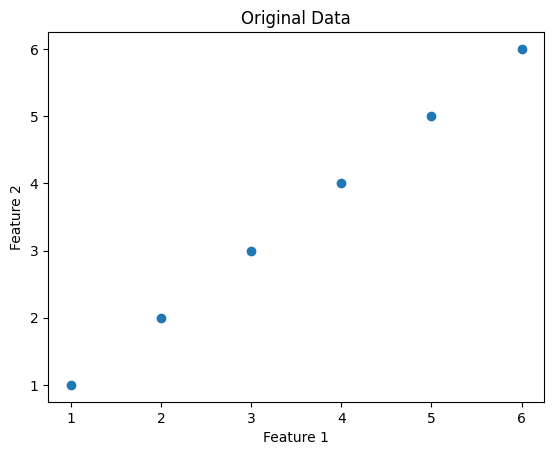

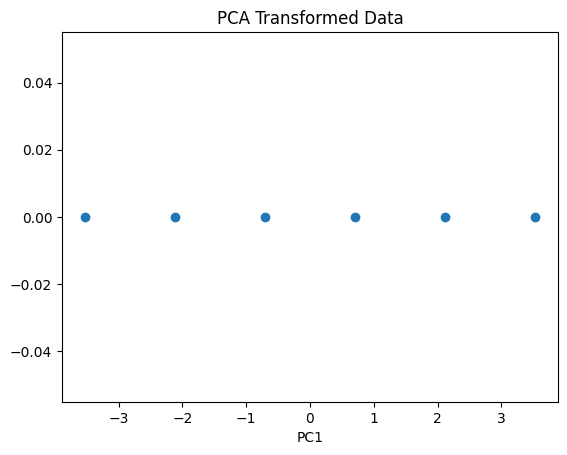

In [34]:
X = np.array([
    [1, 1],
    [2, 2],
    [3, 3],
    [4, 4],
    [5, 5],
    [6, 6]
])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.show()

plt.scatter(X_pca[:, 0], np.zeros(len(X_pca)))
plt.xlabel("PC1")
plt.title("PCA Transformed Data")
plt.show()

## Q17. 3D dataset reduced to 2D and plotted

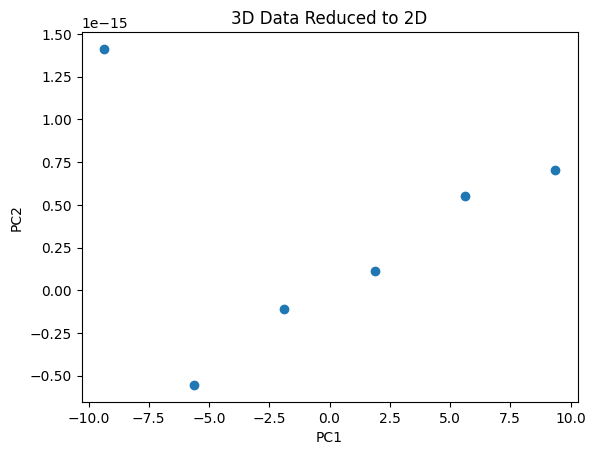

Transformed data:
[[-9.35414347e+00  1.41300306e-15]
 [-5.61248608e+00 -5.54052317e-16]
 [-1.87082869e+00 -1.12085210e-16]
 [ 1.87082869e+00  1.12085210e-16]
 [ 5.61248608e+00  5.54052317e-16]
 [ 9.35414347e+00  7.03306194e-16]]


In [35]:
X = np.array([
    [1, 2, 3],
    [2, 4, 6],
    [3, 6, 9],
    [4, 8, 12],
    [5, 10, 15],
    [6, 12, 18]
])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("3D Data Reduced to 2D")
plt.show()

print("Transformed data:")
print(X_2d)


## Q18. PCA with and without standardization

In [36]:
from sklearn.preprocessing import StandardScaler

X = np.array([
    [1, 100],
    [2, 200],
    [3, 300],
    [4, 400],
    [5, 500]
])

# Without standardization
pca_raw = PCA(n_components=2)
raw_result = pca_raw.fit_transform(X)

# With standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
scaled_result = pca_scaled.fit_transform(X_scaled)

print("PCA without standardization:")
print(raw_result)
print("Explained variance ratio:", pca_raw.explained_variance_ratio_)

print("\nStandardized data:")
print(X_scaled)
print("PCA after standardization:")
print(scaled_result)
print("Explained variance ratio:", pca_scaled.explained_variance_ratio_)

PCA without standardization:
[[-2.00010000e+02 -5.39237060e-16]
 [-1.00005000e+02  1.79745687e-16]
 [ 0.00000000e+00 -0.00000000e+00]
 [ 1.00005000e+02 -1.79745687e-16]
 [ 2.00010000e+02 -3.59491373e-16]]
Explained variance ratio: [1.00000000e+00 4.84579219e-36]

Standardized data:
[[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]
PCA after standardization:
[[-2.00000000e+00  1.48952049e-16]
 [-1.00000000e+00 -4.96506831e-17]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  4.96506831e-17]
 [ 2.00000000e+00  9.93013661e-17]]
Explained variance ratio: [1.00000000e+00 3.69778549e-33]
